In [1]:
import os
import collections
import numpy as np
from numpy.lib.format import open_memmap
from pathlib import Path
from tqdm import tqdm
import openwakeword
import openwakeword.data
import openwakeword.utils
import openwakeword.metrics
from openwakeword.utils import download_models
import scipy
import datasets
import matplotlib.pyplot as plt
import torch
from torch import nn
import IPython.display as ipd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

/home/nero/.cache/pypoetry/virtualenvs/dl-U864L889-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:speechbrain.utils.quirks:Applied quirks (see `speechbrain.utils.quirks`): [disable_jit_profiling, allow_tf32]
INFO:speechbrain.utils.quirks:Excluded quirks specified by the `SB_DISABLE_QUIRKS` environment (comma-separated list): []
INFO:datasets:PyTorch version 2.5.1 available.


In [2]:
PATH= '/home/nero/Projects/master/DL-WakeWord/'

In [4]:
cv_11 = datasets.load_dataset("mozilla-foundation/common_voice_11_0", "en", split="test", streaming=True)
cv_11 = cv_11.cast_column("audio", datasets.Audio(sampling_rate=16000, mono=True)) # convert to 16-khz
cv_11 = cv_11.cast_column("text", datasets.Value("string"))

limit = 5000
for i, example in tqdm(enumerate(cv_11), total=limit):
    if i >= limit:  # Stop if we've reached the limit
        break
    
    output = os.path.join("cv11_test_clips", example["path"][0:-4] + ".wav")
    os.makedirs(os.path.dirname(output), exist_ok=True)

    # Convert the audio array to 16-bit PCM format
    wav_data = (example["audio"]["array"] * 32767).astype(np.int16)
    
    # Save the audio clip as a .wav file
    scipy.io.wavfile.write(output, 16000, wav_data)

Reading metadata...: 16354it [00:00, 20704.75it/s]
  2%|▏         | 115/5000 [00:04<03:30, 23.22it/s]


KeyboardInterrupt: 

In [3]:
download_models(
    target_directory="../models",
)

embedding_model.tflite: 100%|██████████| 1.33M/1.33M [00:00<00:00, 16.9MiB/s]
embedding_model.onnx: 100%|██████████| 1.33M/1.33M [00:00<00:00, 8.66MiB/s]
melspectrogram.tflite: 100%|██████████| 1.09M/1.09M [00:00<00:00, 11.6MiB/s]
melspectrogram.onnx: 100%|██████████| 1.09M/1.09M [00:00<00:00, 16.7MiB/s]
silero_vad.onnx: 100%|██████████| 1.81M/1.81M [00:00<00:00, 15.6MiB/s]
alexa_v0.1.tflite: 100%|██████████| 855k/855k [00:00<00:00, 7.09MiB/s]
alexa_v0.1.onnx: 100%|██████████| 854k/854k [00:00<00:00, 16.2MiB/s]
hey_mycroft_v0.1.tflite: 100%|██████████| 860k/860k [00:00<00:00, 12.2MiB/s]
hey_mycroft_v0.1.onnx: 100%|██████████| 858k/858k [00:00<00:00, 12.7MiB/s]
hey_jarvis_v0.1.tflite: 100%|██████████| 1.28M/1.28M [00:00<00:00, 15.7MiB/s]
hey_jarvis_v0.1.onnx: 100%|██████████| 1.27M/1.27M [00:00<00:00, 18.3MiB/s]
hey_rhasspy_v0.1.tflite: 100%|██████████| 416k/416k [00:00<00:00, 11.2MiB/s]
hey_rhasspy_v0.1.onnx: 100%|██████████| 204k/204k [00:00<00:00, 2.96MiB/s]
timer_v0.1.tflite: 100%|█

In [3]:
import os
#list current directory
os.listdir()
os.getcwd()
F = openwakeword.utils.AudioFeatures(melspec_model_path="/home/nero/Projects/master/DL-WakeWord/models/melspectrogram.onnx", embedding_model_path="/home/nero/Projects/master/DL-WakeWord/models/embedding_model.onnx")

In [4]:
negative_clips, negative_durations = openwakeword.data.filter_audio_paths(
    [
        "/home/nero/Projects/master/DL-WakeWord/data/fma_sample",
        "/home/nero/Projects/master/DL-WakeWord//data/fsd50k_sample",
        "/home/nero/Projects/master/DL-WakeWord/data/cv11_test_clips/en_test_0"
    ],
    min_length_secs = 1.0, # minimum clip length in seconds
    max_length_secs = 60*30, # maximum clip length in seconds
    duration_method = "header" # use the file header to calculate duration
)

print(f"{len(negative_clips)} negative clips after filtering, representing ~{sum(negative_durations)//3600} hours")

200it [00:00, 21921.83it/s]
100%|██████████| 200/200 [00:00<00:00, 3654.77it/s]
1000it [00:00, 95666.45it/s]
100%|██████████| 1000/1000 [00:00<00:00, 4955.56it/s]
5000it [00:00, 127700.70it/s]
100%|██████████| 5000/5000 [00:01<00:00, 4707.97it/s]

6096 negative clips after filtering, representing ~12.0 hours


In [5]:
from datasets import Dataset, Audio

audio_dataset = Dataset.from_dict({"audio": negative_clips})
audio_dataset = audio_dataset.cast_column("audio", Audio(sampling_rate=16000))
print(len(negative_clips))

6096


In [6]:
# Get audio embeddings (features) for negative clips and save to .npy file
batch_size = 64 # number of files to load, compute features, and write to mmap at a time
clip_size = 3  # the desired window size (in seconds) for the trained openWakeWord model
N_total = int(sum(negative_durations)//clip_size) # maximum number of rows in mmap file
n_feature_cols = F.get_embedding_shape(clip_size)

output_file = "negative_features.npy"
output_array_shape = (N_total, n_feature_cols[0], n_feature_cols[1])
fp = open_memmap(output_file, mode='w+', dtype=np.float32, shape=output_array_shape)

row_counter = 0
for i in tqdm(np.arange(0, audio_dataset.num_rows, batch_size)):
    # Load data in batches and shape into rectangular array
    wav_data = [(j["array"]*32767).astype(np.int16) for j in audio_dataset[i:i+batch_size]["audio"]]
    wav_data = openwakeword.data.stack_clips(wav_data, clip_size=16000*clip_size).astype(np.int16)
    
    # Compute features (increase ncpu argument for faster processing)
    features = F.embed_clips(x=wav_data, batch_size=1024, ncpu=8)
    
    # Save computed features to mmap array file (stopping once the desired size is reached)
    if row_counter + features.shape[0] > N_total:
        fp[row_counter:min(row_counter+features.shape[0], N_total), :, :] = features[0:N_total - row_counter, :, :]
        fp.flush()
        break
    else:
        fp[row_counter:row_counter+features.shape[0], :, :] = features
        row_counter += features.shape[0]
        fp.flush()
        
# Trip empty rows from the mmapped array
openwakeword.data.trim_mmap(output_file)

 98%|█████████▊| 94/96 [09:40<00:12,  6.17s/it]
Trimming empty rows: 15it [00:00, 34.21it/s]                        


In [7]:
# Get positive example paths, filtering out clips that are too long or too short

positive_clips, durations = openwakeword.data.filter_audio_paths(
    [
        "/home/nero/Projects/master/DL-WakeWord/data/turn_on_the_office_lights"
    ],
    min_length_secs = 1.0, # minimum clip length in seconds
    max_length_secs = 2.0, # maximum clip length in seconds
    duration_method = "header" # use the file header to calculate duration
)

print(f"{len(positive_clips)} positive clips after filtering")

3388it [00:00, 48410.43it/s]
100%|██████████| 3388/3388 [00:00<00:00, 4772.85it/s]

3203 positive clips after filtering


In [8]:
# Define starting point for each positive clip based on its length, so that each one ends 
# between 0-200 ms from the end of the total window size chosen for the model.

# Get start and end positions for the positive audio in the full window
sr = 16000
total_length_seconds = 3 # must be the some window length as that used for the negative examples
total_length = int(sr*total_length_seconds)

jitters = (np.random.uniform(0, 0.2, len(positive_clips))*sr).astype(np.int32)
starts = [total_length - (int(np.ceil(i*sr))+j) for i,j in zip(durations, jitters)]
ends = [int(i*sr) + j for i, j in zip(durations, starts)]

# Create generator to mix the positive audio with background audio
batch_size = 8
mixing_generator = openwakeword.data.mix_clips_batch(
    foreground_clips = positive_clips,
    background_clips = negative_clips,
    combined_size = total_length,
    batch_size = batch_size,
    snr_low = 5,
    snr_high = 15,
    start_index = starts,
    volume_augmentation=True, # randomly scale the volume of the audio after mixing
)
print(f"Number of positive clips: {len(positive_clips)}")
print(f"Number of negative clips: {len(negative_clips)}")
print(torch.__version__)
try:
    mixed_clips, labels, background_clips = next(mixing_generator)
    print(f"Mixed Clips: {mixed_clips}")
    print(f"Labels: {labels}")
    print(f"Background Clips: {background_clips}")
except StopIteration:
    print("Generator has no more data.")



Number of positive clips: 3203
Number of negative clips: 6096
2.5.1+cu124
Mixed Clips: [[   8    9    7 ...    0    2    1]
 [   0    0    0 ...  168  234  297]
 [   0    0    0 ...   -2   -3   -4]
 ...
 [   1    5    7 ...    6    4    2]
 [   1    1    0 ... -280 -294 -289]
 [ -74  -37 -104 ...   52   -7  -89]]
Labels: [0 0 0 0 0 0 0 0]
Background Clips: None


In [9]:

mixed_clips, labels, background_clips = next(mixing_generator)
ipd.display(ipd.Audio(mixed_clips[0], rate=16000, normalize=True, autoplay=False))

In [10]:
def get_embeddings(x: np.ndarray, window_size: int = 76, step_size: int = 8, **kwargs):
        """Function to compute the embeddings of the provide audio samples."""
        spec = F._get_melspectrogram(x, **kwargs)
        print(spec.shape)
        windows = []
        for i in range(0, spec.shape[0], 8):
            window = spec[i:i+window_size]
            if window.shape[0] == window_size:  # truncate short windows
                windows.append(window)

        batch = np.expand_dims(np.array(windows), axis=-1).astype(np.float32)
        print("batch shape",batch.shape)
        embedding = F.embedding_model_predict(batch)
        return embedding

In [11]:
print(len(positive_clips))

N_total = len(positive_clips)
x = (np.random.uniform(-1, 1, int(3*16000))*32767).astype(np.int16)
print(x)
n_feature_cols = get_embeddings(x).shape
print(n_feature_cols)

3203
[31088 15190 -4556 ... 18790 22619 28918]
(297, 32)
batch shape (28, 76, 32, 1)
(28, 96)


In [15]:
# Iterate through the mixing generator, computing audio features for positive examples and saving them

N_total = len(positive_clips) # maximum number of rows in mmap file
n_feature_cols = F.get_embedding_shape(total_length_seconds)

output_file = "turn_on_the_office_lights_features.npy"
output_array_shape = (N_total, n_feature_cols[0], n_feature_cols[1])

fp = open_memmap(output_file, mode='w+', dtype=np.float32, shape=output_array_shape)

row_counter = 0
for batch in tqdm(mixing_generator, total=N_total//batch_size):
    batch, lbls, background = batch[0], batch[1], batch[2]
    
    # Compute audio features

    melspecs = F._get_melspectrogram_batch(batch, batch_size=batch_size, ncpu=1)
    """
    # Visualize the first spectrogram in the batch
    plt.figure(figsize=(10, 6))
    plt.title("Mel Spectrogram")
    plt.imshow(melspecs[0].T, aspect='auto', origin='lower', interpolation='nearest')
    plt.colorbar(label="Log-scaled Amplitude")
    plt.xlabel("Time Frames")
    plt.ylabel("Mel Frequency Bins")
    plt.show()
    
    # Listen to the first audio sample in the batch
    first_audio_clip = batch[0]  # Extract the first audio clip (raw waveform)
    sample_rate = 16000  # Assume audio is sampled at 16 kHz
    ipd.display(ipd.Audio(first_audio_clip, rate=sample_rate))
    """
    embeddings = F._get_embeddings_batch(melspecs[:, :, :, None], batch_size=batch_size, ncpu=1)
    """
    # Visualize the embeddings in 3D space
    embedding_sample = embeddings[0].reshape(-1, embeddings.shape[-1])  # Flatten time and feature dimensions
    
    # Apply PCA or t-SNE for dimensionality reduction to 3D
    # Use PCA for faster computation, or t-SNE for better visual separation
    pca = PCA(n_components=3)
    embeddings_3d = pca.fit_transform(embedding_sample)
    
    # Plot the 3D embeddings
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(embeddings_3d[:, 0], embeddings_3d[:, 1], embeddings_3d[:, 2], c=np.arange(len(embeddings_3d)), cmap='viridis')
    ax.set_title("3D Representation of Embeddings")
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")
    ax.set_zlabel("PCA Component 3")
    plt.show()
    
    
    # Print shape of the first embedding
    print(f"Embedding shape: {embedding_sample.shape}")
    """
    features = embeddings
    
    # Save computed features
    fp[row_counter:row_counter+features.shape[0], :, :] = features
    row_counter += features.shape[0]
    fp.flush()
    if row_counter >= N_total:
        break

# Trip empty rows from the mmapped array
openwakeword.data.trim_mmap(output_file)

 30%|███       | 121/400 [01:31<03:14,  1.44it/s]/home/nero/.cache/pypoetry/virtualenvs/dl-U864L889-py3.11/lib/python3.11/site-packages/openwakeword/data.py:463: RuntimeWarning: invalid value encountered in cast
  mixed_clips_batch = (mixed_clips_batch.numpy()*32767).astype(np.int16)
 95%|█████████▌| 380/400 [05:16<00:16,  1.20it/s]
Trimming empty rows: 4it [00:00, 34.08it/s]                       


In [3]:


# Load the data prepared in previous steps (it's small enough to load entirely in memory)
negative_features = np.load("negative_features.npy")
positive_features = np.load("turn_on_the_office_lights_features.npy")

X = np.vstack((negative_features, positive_features))
y = np.array([0]*len(negative_features) + [1]*len(positive_features)).astype(np.float32)[..., None]

# Make Pytorch dataloader
batch_size = 512
training_data = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.from_numpy(X), torch.from_numpy(y)),
    batch_size=batch_size,
    shuffle=True
)

# Define fully-connected network in PyTorch
layer_dim = 32
fcn = nn.Sequential(
    nn.Flatten(),
    nn.Linear(X.shape[1]*X.shape[2], layer_dim),  # Input: (timesteps*feature columns) -> 32
    nn.LayerNorm(layer_dim),
    nn.ReLU(),
    nn.Linear(layer_dim, layer_dim),              # 32 -> 32
    nn.LayerNorm(layer_dim),
    nn.ReLU(),
    nn.Linear(layer_dim, 1),                        # 32 -> 1
    nn.Sigmoid()
)

loss_function = torch.nn.functional.binary_cross_entropy
optimizer = torch.optim.Adam(fcn.parameters(), lr=0.001)

# Helper function to count trainable parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(fcn)
print("Total trainable parameters: ", total_params)

# (Optional) Print a breakdown for each parameter group
for name, param in fcn.named_parameters():
    if param.requires_grad:
        print(f"{name}: {param.numel()}")

# Expected formula (manual calculation):
# Let D = X.shape[1] * X.shape[2]
# First Linear: 32*D + 32 biases
# First LayerNorm: 2*32 = 64
# Second Linear: 32*32 + 32 = 1024 + 32 = 1056
# Second LayerNorm: 2*32 = 64
# Third Linear: 32*1 + 1 = 32 + 1 = 33
# Total = 32*D + 32 + 64 + 1056 + 64 + 33 = 32*D + 1249
print(f"Expected parameter count (manual): 32 * (X.shape[1]*X.shape[2]) + 1249 = {32*(X.shape[1]*X.shape[2]) + 1249}")


Total trainable parameters:  87265
1.weight: 86016
1.bias: 32
2.weight: 32
2.bias: 32
4.weight: 1024
4.bias: 32
5.weight: 32
5.bias: 32
7.weight: 32
7.bias: 1
Expected parameter count (manual): 32 * (X.shape[1]*X.shape[2]) + 1249 = 87265


In [17]:
# Define training loop, metrics, and logging

n_epochs = 10
history = collections.defaultdict(list)
for i in tqdm(range(n_epochs), total=n_epochs):
    for batch in training_data:
        # Get data for batch
        x, y = batch[0], batch[1]
        weights = torch.ones(y.shape[0])
        weights[y.flatten() == 1] = 0.1
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Run forward pass
        predictions = fcn(x)
        
        # Update model parameters
        loss = loss_function(predictions, y, weights[..., None])
        loss.backward()
        optimizer.step()
        
        # Log metrics
        history['loss'].append(float(loss.detach().numpy()))
        
        tp = sum(predictions.flatten()[y.flatten() == 1] >= 0.5)
        fn = sum(predictions.flatten()[y.flatten() == 1] < 0.5)
        history['recall'].append(float(tp/(tp+fn).detach().numpy()))

100%|██████████| 10/10 [00:06<00:00,  1.48it/s]


(0.0, 1.0)

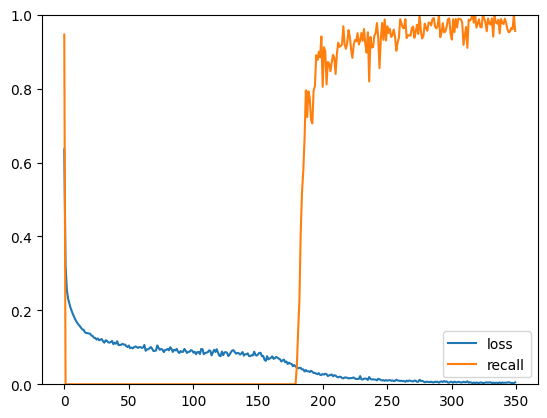

In [18]:

plt.figure()
plt.plot(history['loss'], label="loss")
plt.plot(history['recall'], label="recall")
plt.legend()
plt.ylim(0,1)

  0%|          | 0/394 [00:00<?, ?it/s]/tmp/ipykernel_4388/92441006.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  scores.append(float(fcn(torch.from_numpy(window)).detach().numpy()))
100%|██████████| 394/394 [00:00<00:00, 4306.20it/s]


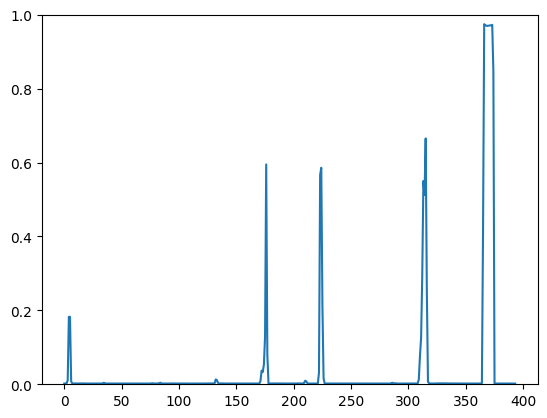

In [19]:
# Load data
sr, dat = scipy.io.wavfile.read("/home/nero/Projects/master/DL-WakeWord/data/turn_on_the_office_lights_test_clip.wav")

features = F._get_embeddings(dat)
ipd.display(ipd.Audio(dat, rate=16000, normalize=True, autoplay=False))
scores = []
for i in tqdm(range(0, features.shape[0]-28)): # 28 is the number of timestep frames for this model
    window = features[i:i+28][None,]
    with torch.no_grad():
        scores.append(float(fcn(torch.from_numpy(window)).detach().numpy()))
    
plt.figure()
_ = plt.plot(scores)
_ = plt.ylim(0,1) 